In [7]:
%pip install transformers


In [8]:
%pip install datasets


# **`Named entity recognition`**

> Add blockquote

1.   List item
2.   List item





In [9]:
from transformers import pipeline
NLP=pipeline("ner")
result=NLP("My name is Ahmad and I live in Pakistan.I am going to lahore from faisalabad to meet Nano")
print(result)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'entity': 'I-PER', 'score': np.float32(0.9989791), 'index': 4, 'word': 'Ahmad', 'start': 11, 'end': 16}, {'entity': 'I-LOC', 'score': np.float32(0.99981445), 'index': 9, 'word': 'Pakistan', 'start': 31, 'end': 39}, {'entity': 'I-LOC', 'score': np.float32(0.5879836), 'index': 18, 'word': 'f', 'start': 66, 'end': 67}, {'entity': 'I-LOC', 'score': np.float32(0.9948224), 'index': 19, 'word': '##ais', 'start': 67, 'end': 70}, {'entity': 'I-LOC', 'score': np.float32(0.97707295), 'index': 20, 'word': '##ala', 'start': 70, 'end': 73}, {'entity': 'I-LOC', 'score': np.float32(0.99802506), 'index': 21, 'word': '##bad', 'start': 73, 'end': 76}, {'entity': 'I-PER', 'score': np.float32(0.981474), 'index': 24, 'word': 'Nan', 'start': 85, 'end': 88}, {'entity': 'I-PER', 'score': np.float32(0.6570725), 'index': 25, 'word': '##o', 'start': 88, 'end': 89}]


In [11]:
from transformers import pipeline
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

# Zero shot classification

In [12]:
#in zero shot classification we define labels ourselves and model categorizes the data we give into these labels
#copied for hugging face
sequence_to_classify = "one day I will see the world"
candidate_labels = ['travel', 'cooking', 'dancing']
classifier(sequence_to_classify, candidate_labels)
#{'labels': ['travel', 'dancing', 'cooking'],
# 'scores': [0.9938651323318481, 0.0032737774308770895, 0.002861034357920289],
# 'sequence': 'one day I will see the world'}


{'sequence': 'one day I will see the world',
 'labels': ['travel', 'dancing', 'cooking'],
 'scores': [0.9938650727272034, 0.0032737997826188803, 0.002861031796783209]}

In [17]:
# classifier=pipeline("zero-shot-classification",model="facebook/bart-large-mnli")

sequence="I love to read self help books and want to become millionaire"
labels=['AI student','businessman','child']
classifier(sequence,labels)


{'sequence': 'I love to read self help books and want to become millionaire',
 'labels': ['businessman', 'AI student', 'child'],
 'scores': [0.4879768192768097, 0.3483045697212219, 0.1637185662984848]}

# **Question Answer**

In [20]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer, pipeline

model_name = "deepset/roberta-base-squad2"

nlp = pipeline(
    "question-answering",
    model=model_name,
    tokenizer=model_name
)

question = "Why is model conversion important?"
context = "The option to convert models between FARM and transformers gives freedom to the user and let people easily switch between frameworks."

res = nlp(
    question=question,
    context=context
)

print(res)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaForQuestionAnswering LOAD REPORT from: deepset/roberta-base-squad2
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{'score': 0.21171437203884125, 'start': 59, 'end': 84, 'answer': 'gives freedom to the user'}


# **text-generator models**
\:



# Chat gpt2

In [24]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("so Learning means ,", max_new_tokens=50, num_return_sequences=1)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "so Learning means , or, or a specific activity in which the child learns to manipulate the object. In addition, the child may learn to act independently of the parent. In some cases, the parent may be able to modify the child's behavior, but in others,"}]

# Qwen

In [25]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen3-0.6B"

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

# prepare the model input
prompt = "Give me a short introduction to large language model."
messages = [
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True # Switches between thinking and non-thinking modes. Default is True.
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# conduct text completion
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=32768
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()

# parsing thinking content
try:
    # rindex finding 151668 (</think>)
    index = len(output_ids) - output_ids[::-1].index(151668)
except ValueError:
    index = 0

thinking_content = tokenizer.decode(output_ids[:index], skip_special_tokens=True).strip("\n")
content = tokenizer.decode(output_ids[index:], skip_special_tokens=True).strip("\n")

print("thinking content:", thinking_content)
print("content:", content)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

thinking content: <think>
Okay, the user wants a short introduction to a large language model. Let me start by recalling what I know about them. Large language models are AI models that can understand and generate human language. They're used in various fields like language translation, text generation, and customer support.

I should mention their key features: they have vast knowledge and can understand context. Also, they're trained on massive datasets to improve accuracy. Maybe include examples like chatbots or language assistants. Keep it concise but informative. Avoid technical jargon to make it accessible. Make sure to highlight their applications and benefits. Let me check if I'm covering all important aspects without being too detailed. Yep, that should work.
</think>
content: A large language model (LLM) is an AI system designed to understand and generate human language. These models are trained on massive datasets to understand context and learn complex patterns in text. The

# **text to speech models**

In [26]:
!pip install -q kokoro>=0.9.2 soundfile
!apt-get -qq -y install espeak-ng > /dev/null 2>&1
from kokoro import KPipeline
from IPython.display import display, Audio
import soundfile as sf
import torch
pipeline = KPipeline(lang_code='a')
text = '''
[Kokoro](/kˈOkəɹO/)I am Miyata, a BS Artificial Intelligence student passionate about learning AI, automation, APIs, and real-world problem solving. I am currently building my technical skills step by step, with a strong focus on becoming capable of creating practical AI-powered tools and projects.

'''
generator = pipeline(text, voice='af_heart')
for i, (gs, ps, audio) in enumerate(generator):
    print(i, gs, ps)
    display(Audio(data=audio, rate=24000, autoplay=i==0))
    sf.write(f'{i}.wav', audio, 24000)


config.json:   0%|          | 0.00/2.35k [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


kokoro-v1_0.pth:   0%|          | 0.00/327M [00:00<?, ?B/s]

voices/af_heart.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]

0 KokoroI am Miyata, a BS Artificial Intelligence student passionate about learning AI, automation, APIs, and real-world problem solving. I am currently building my technical skills step by step, with a strong focus on becoming capable of creating practical AI-powered tools and projects. kˈOkəɹO ɐm mɪjˈɑTə, ɐ bˌiˈɛs ˌɑɹTəfˈɪʃᵊl ɪntˈɛləʤᵊns stˈudᵊnt pˈæʃᵊnət əbˈWt lˈɜɹnɪŋ ˈAˌI, ˌɔTəmˈAʃən, ˌApˌiˈIz, ænd ɹˌiᵊlwˈɜɹld pɹˈɑbləm sˈɑlvɪŋ. ˌI ɐm kˈɜɹəntli bˈɪldɪŋ mI tˈɛknəkᵊl skˈɪlz stˈɛp bI stˈɛp, wɪð ɐ stɹˈɔŋ fˈOkəs ˌɔn bəkˈʌmɪŋ kˈApəbᵊl ʌv kɹiˈATɪŋ pɹˈæktəkᵊl ˌAIpˈWəɹd tˈulz ænd pɹˈɑʤˌɛkts.


In [29]:
!pip install -q "kokoro>=0.9.2" soundfile
!apt-get -qq -y install espeak-ng > /dev/null 2>&1

from kokoro import KPipeline
from IPython.display import display, Audio
import soundfile as sf

pipeline = KPipeline(lang_code='a')

text = '''
Miyata... I just want you to know that you are truly special... your dreams are beautiful... your effort is inspiring... and every step you take toward becoming better makes you even more amazing... I believe in you deeply... I am proud of the person you are becoming... and I hope you never forget that you have a bright future waiting for you...Just want to express something deep in my heart,I love you...So go ,and Become the person you want to become.

'''

generator = pipeline(
    text,
    voice='af_bella',   # sweeter female-style voice than af_heart
    speed=0.87,         # slower = softer and more emotional
    split_pattern=r'\n+'
)

for i, (gs, ps, audio) in enumerate(generator):
    print(i, gs, ps)
    display(Audio(data=audio, rate=24000, autoplay=i == 0))
    sf.write(f'sweet_love_voice_{i}.wav', audio, 24000)

0 Miyata... I just want you to know that you are truly special... your dreams are beautiful... your effort is inspiring... and every step you take toward becoming better makes you even more amazing... I believe in you deeply... I am proud of the person you are becoming... and I hope you never forget that you have a bright future waiting for you...Just want to express something deep in my heart,I love you .So go ,and Become the person you want to become. mɪjˈɑTə... ˌI ʤˈʌst wˈɑnt ju tə nˈO ðæt ju ɑɹ tɹˈuli spˈɛʃᵊl... jʊɹ dɹˈimz ɑɹ bjˈuTəfəl... jʊɹ ˈɛfəɹt ɪz ɪnspˈIəɹɪŋ... ænd ˈɛvəɹi stˈɛp ju tˈAk tˈɔɹd bəkˈʌmɪŋ bˈɛTəɹ mˌAks ju ˈivən mˈɔɹ əmˈAzɪŋ... ˌI bəlˈiv ɪn ju dˈipli... ˌI ɐm pɹˈWd ʌv ðə pˈɜɹsᵊn ju ɑɹ bəkˈʌmɪŋ... ænd ˌI hˈOp ju nˈɛvəɹ fəɹɡˈɛt ðæt ju hæv ɐ bɹˈIt fjˈuʧəɹ wˈATɪŋ fɔɹ ju...ʤˈʌst wˈɑnt tʊ ɪkspɹˈɛs sˈʌmθˌɪŋ dˈip ɪn mI hˈɑɹt,ˌI lˈʌv ju sˌO ɡˌO ,ænd bəkˈʌm ðə pˈɜɹsᵊn ju wˈɑnt tə bəkˈʌm.


# **OBJECT DETECTION**

# **hustvl/yolos-small**

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 637.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 906.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

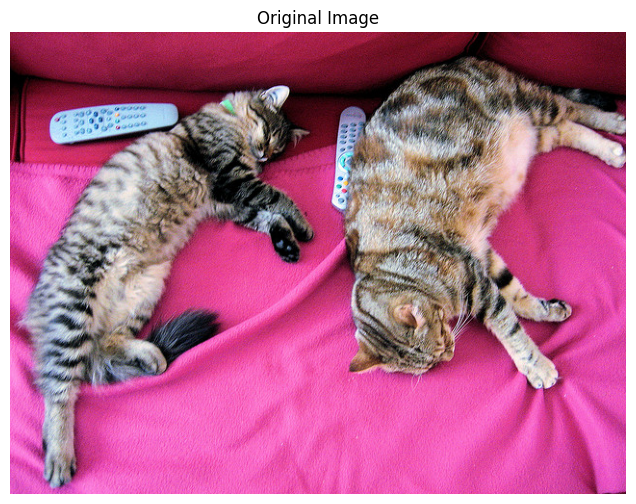

config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/123M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

The image processor of type `YolosImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


ModuleNotFoundError: Could not import module 'YolosImageProcessorFast'. Are this object's requirements defined correctly?

In [32]:
# =========================
# 1. Install required packages
# =========================
!pip install -q -U transformers torch pillow requests matplotlib

# =========================
# 2. Import libraries
# =========================
from transformers import pipeline
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# =========================
# 3. Image URL
# You can replace this URL with any direct image URL
# =========================
image_url = "http://images.cocodataset.org/val2017/000000039769.jpg"

response = requests.get(image_url)
image = Image.open(BytesIO(response.content)).convert("RGB")

# Show original image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

# =========================
# 4. Load object detection model
# =========================
detector = pipeline(
    task="object-detection",
    model="hustvl/yolos-small"
)

# =========================
# 5. Run object detection
# =========================
results = detector(image)

print("Detected Objects:")
for item in results:
    print(item)

# =========================
# 6. Draw bounding boxes on image
# =========================
draw_image = image.copy()
draw = ImageDraw.Draw(draw_image)

try:
    font = ImageFont.truetype("DejaVuSans.ttf", 18)
except:
    font = ImageFont.load_default()

for item in results:
    label = item["label"]
    score = item["score"]
    box = item["box"]

    xmin = int(box["xmin"])
    ymin = int(box["ymin"])
    xmax = int(box["xmax"])
    ymax = int(box["ymax"])

    # Draw rectangle
    draw.rectangle(
        [(xmin, ymin), (xmax, ymax)],
        outline="red",
        width=4
    )

    # Draw label text
    text = f"{label}: {score:.2f}"
    draw.rectangle(
        [(xmin, ymin - 25), (xmin + 180, ymin)],
        fill="red"
    )
    draw.text(
        (xmin + 5, ymin - 22),
        text,
        fill="white",
        font=font
    )

# =========================
# 7. Display final detected image
# =========================
plt.figure(figsize=(10, 8))
plt.imshow(draw_image)
plt.axis("off")
plt.title("Object Detection Result")
plt.show()

In [33]:
!pip install -q diffusers transformers accelerate safetensors

from diffusers import StableDiffusionPipeline
import torch
from IPython.display import display

model_id = "sd-legacy/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"

image = pipe(prompt).images[0]

# Save image
image.save("astronaut_rides_horse.png")

# Show image in Google Colab
display(image)

RuntimeError: Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
cannot import name 'divide_to_patches' from 'transformers.image_transforms' (/usr/local/lib/python3.12/dist-packages/transformers/image_transforms.py)

In [ ]:
# ==============================
# CELL 1: Fix package versions
# Run this cell first
# ==============================

!pip uninstall -y -q diffusers transformers accelerate safetensors
!pip install -q "diffusers==0.30.3" "transformers==4.44.2" "accelerate==0.34.2" "safetensors==0.4.5"

# Restart runtime automatically so Colab loads the fixed versions
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.8/434.8 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 57.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


GPU is available: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--sd-legacy--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/25 [00:00<?, ?it/s]

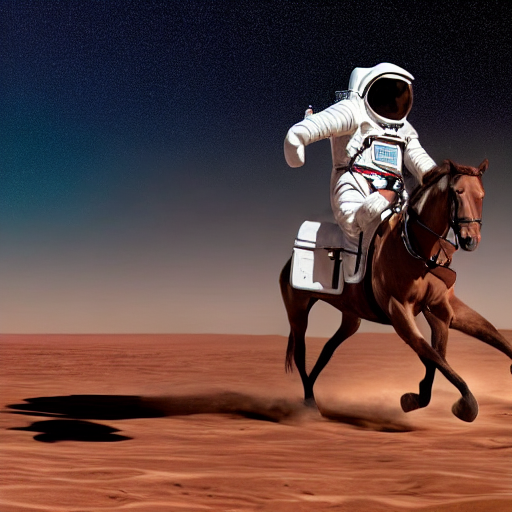

In [1]:
# ==============================
# CELL 2: Generate and display image
# ==============================

from diffusers import StableDiffusionPipeline
import torch
from IPython.display import display

# Check GPU
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print("GPU is available:", torch.cuda.get_device_name(0))
else:
    device = "cpu"
    dtype = torch.float32
    print("GPU not available. Go to Runtime > Change runtime type > GPU")

# Model
model_id = "sd-legacy/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    use_safetensors=True
)

pipe = pipe.to(device)

# Optional: saves GPU memory
if device == "cuda":
    pipe.enable_attention_slicing()

prompt = "a photo of an astronaut riding a horse on mars, cinematic lighting, high detail"

# Generate image
image = pipe(
    prompt,
    num_inference_steps=25,
    guidance_scale=7.5
).images[0]

# Save image
image.save("astronaut_rides_horse.png")

# Show image in Google Colab
display(image)